# AccidentLens: Deep Model Training & Optimization

**Objective**: This notebook details the development of a high-accuracy classifier for predicting accident severity. We move from raw data to a production-ready serialized model pipeline.

---

## 1. Pipeline Setup
We use scikit-learn's `Pipeline` and `ColumnTransformer` to ensure that preprocessing and modeling are bundled together, preventing data leakage and simplifying deployment.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    roc_auc_score
)
import pickle

# Robust Data Loading
data_path = 'data/accident_data.csv'
if not os.path.exists(data_path):
    data_path = 'python-analysis/notebook/data/accident_data.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    df.columns = [col.replace(' ', '_') for col in df.columns]
    print("Dataset loaded successfully!")
else:
    print(f"Error: Data file not found at {data_path}.")

df.head()

Dataset loaded successfully!


,State_Name,City_Name,Year,Month,Day_of_Week,Time_of_Day,Accident_Severity,Number_of_Vehicles_Involved,Vehicle_Type_Involved,Number_of_Casualties,...,Road_Type,Road_Condition,Lighting_Conditions,Traffic_Control_Presence,Speed_Limit_(km/h),Driver_Age,Driver_Gender,Driver_License_Status,Alcohol_Involvement,Accident_Location_Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


## 2. Feature Engineering
Transforming raw fields into model-ready features.

In [5]:
# Extract hour for time-based features
df['Hour'] = df['Time_of_Day'].apply(lambda x: int(x.split(':')[0]))

# Define feature sets
categorical_features = [
    'Weather_Conditions', 'Road_Type', 'Lighting_Conditions', 
    'Vehicle_Type_Involved', 'Driver_Gender', 'Alcohol_Involvement'
]
numerical_features = [
    'Number_of_Vehicles_Involved', 'Number_of_Casualties', 'Driver_Age', 
    'Speed_Limit_(km/h)', 'Hour'
]
target = 'Accident_Severity'

X = df[categorical_features + numerical_features]
y = df[target]

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")

Training set size: (2400, 11)


## 3. Pipeline Construction
Building a robust preprocessing and modeling flow.

In [6]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Model Definition
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Create full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

## 4. Hyperparameter Tuning
Using GridSearchCV to find the optimal parameters for the Random Forest.

In [7]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


## 5. Model Evaluation
Rigorous testing on the hold-out set.

--- Classification Report ---
              precision    recall  f1-score   support

       Fatal       0.27      0.26      0.26       197
       Minor       0.35      0.37      0.36       207
     Serious       0.34      0.33      0.34       196

    accuracy                           0.32       600
   macro avg       0.32      0.32      0.32       600
weighted avg       0.32      0.32      0.32       600



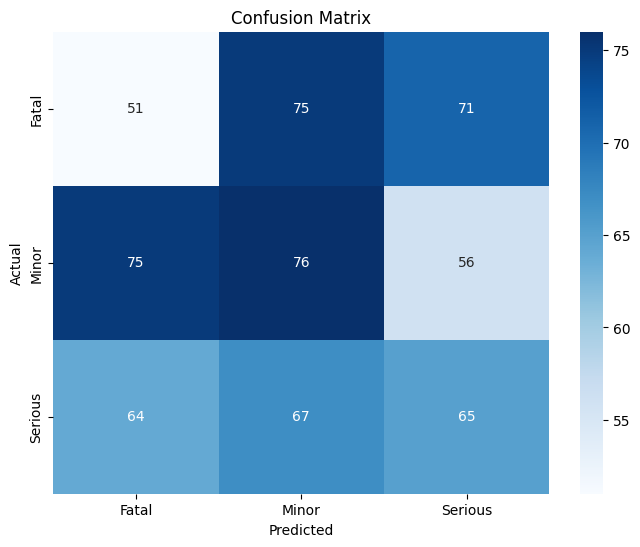

In [8]:
y_pred = best_model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Feature Importance
What factors contribute most to the severity prediction?

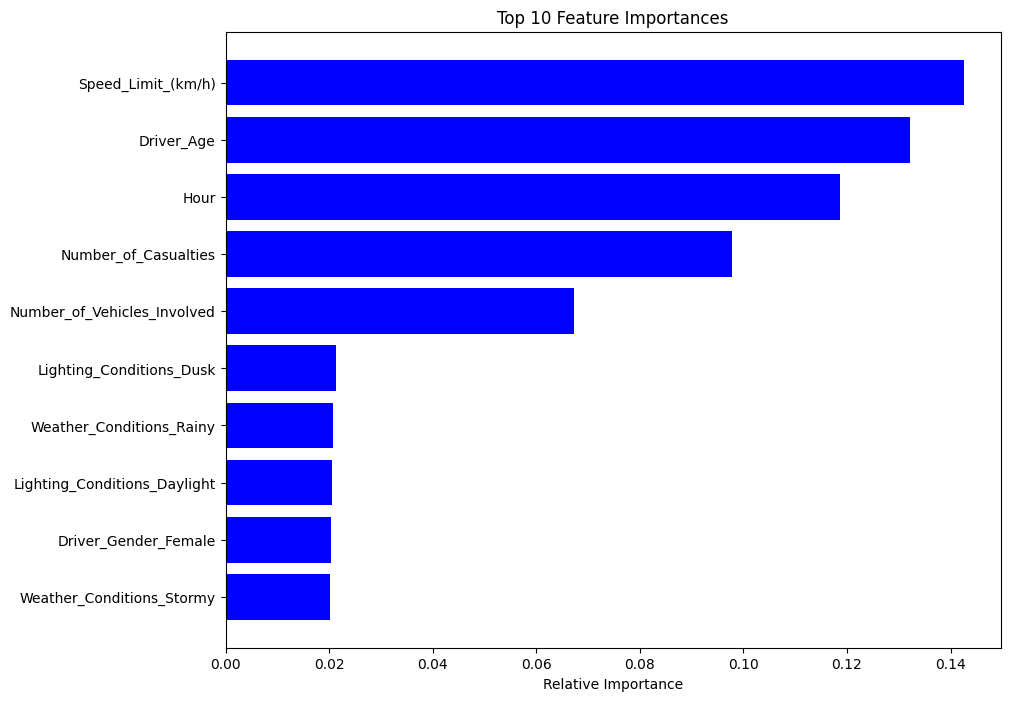

In [9]:
# Get feature names from preprocessor
ohe_feature_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, ohe_feature_names])

importances = best_model.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 8))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 7. Model Serialization
Saving the best model for real-time inference in our Flask app.

In [10]:
# Determine artifact path relative to notebook
artifact_dir = '../artifacts'
if not os.path.exists(artifact_dir):
    artifact_dir = 'python-analysis/artifacts'
os.makedirs(artifact_dir, exist_ok=True)

with open(os.path.join(artifact_dir, 'model.pkl'), 'wb') as f:
    pickle.dump(best_model.named_steps['classifier'], f)

with open(os.path.join(artifact_dir, 'preprocessor.pkl'), 'wb') as f:
    pickle.dump(best_model.named_steps['preprocessor'], f)

with open(os.path.join(artifact_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f"✅ Production artifacts successfully saved in {artifact_dir} folder.")

✅ Production artifacts successfully saved in ../artifacts folder.
